# AlexNet feature extraction (per-layer)

This notebook extracts **AlexNet** features **after each pooling or ReLU** for the same 32 images (8 categories × 4 instances).

- Input images are **64×264** grayscale; we convert them to RGB and apply ImageNet normalization.
- For convolutional layers, we save both:
  - **feature maps** (B, C, H, W) per layer (optional, can be large)
  - a compact **pooled vector** per image via global average pooling
  
Outputs are written to `outputs/`.


In [1]:
import os
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [2]:
# Load the 32 images 
from scipy.io import loadmat

datapath = '../data'
filename = 'miguel_passive8x4.mat'
filepath = os.path.join(datapath, filename)

mat = loadmat(filepath)
img = mat['img'].astype(np.float32)  # expected shape (H, W, N) or similar
images_gray = np.transpose(img, (2, 0, 1))  # (N, H, W)
print('images_gray:', images_gray.shape, images_gray.min(), images_gray.max())

nimg = len(images_gray)
img_class = np.repeat(np.arange(nimg // 4), 4)  # 8 categories × 4 images
print("nimg:", nimg, "img_class:", img_class.shape, "unique:", np.unique(img_class))


images_gray: (32, 150, 600) 0.0 255.0
nimg: 32 img_class: (32,) unique: [0 1 2 3 4 5 6 7]


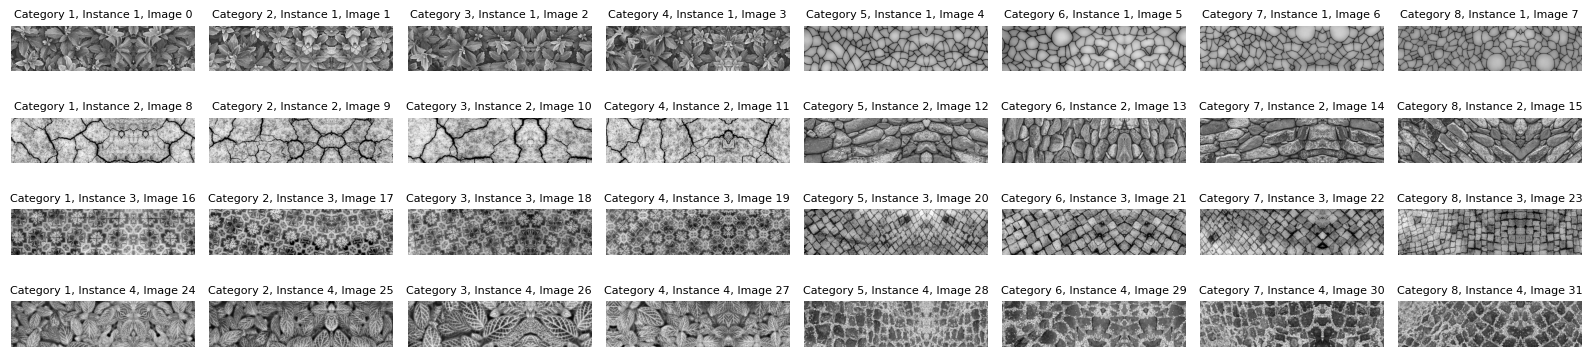

In [13]:
# visualize the images in 4x8 grid with category and instance labels, with each category for each column
import matplotlib.pyplot as plt
fig, axes = plt.subplots(4, 8, figsize=(16, 4))
for i in range(4):
    for j in range(8):
        idx = i * 8 + j
        axes[i, j].imshow(images_gray[idx], cmap='gray')
        axes[i, j].axis('off')
        # add category and instance labels
        axes[i, j].set_title(f'Category {j+1}, Instance {i+1}, Image {idx}', fontsize=8)
plt.tight_layout()
plt.savefig('../figures/images.png', dpi=300)
plt.show()

In [65]:
# Convert to RGB PIL images
images_rgb = []
for i in range(nimg):
    im = images_gray[i]
    pil = Image.fromarray(im).convert('RGB')
    images_rgb.append(pil)

print("Converted:", len(images_rgb), "images. Example size:", images_rgb[0].size)  # (W,H)

Converted: 32 images. Example size: (600, 150)


In [66]:
# Preprocess for AlexNet (ImageNet normalization)
import torchvision.transforms as T

mean = (0.485, 0.456, 0.406)
std  = (0.229, 0.224, 0.225)

transform = T.Compose([
    T.Resize((64, 264)), 
    T.ToTensor(),               
    T.Normalize(mean=mean, std=std)
])

# stack into a batch tensor (B,3,H,W)
x = torch.stack([transform(im) for im in images_rgb], dim=0)
print("Input batch:", x.shape, x.dtype, "device:", x.device)

Input batch: torch.Size([32, 3, 64, 264]) torch.float32 device: cpu


In [67]:
# Load AlexNet
import torchvision
from torchvision.models import alexnet, AlexNet_Weights

weights = AlexNet_Weights.IMAGENET1K_V1
model = alexnet(weights=weights).to(device).eval()

In [68]:
# Register hooks to capture outputs AFTER each layer
from collections import OrderedDict

relu_module_names = [
    "features.2",  
    "features.5", 
    "features.7",  
    "features.9", 
    "features.12"
]

def get_module_by_name(m, name: str):
    cur = m
    for part in name.split('.'):
        if part.isdigit():
            cur = cur[int(part)]
        else:
            cur = getattr(cur, part)
    return cur

captured = OrderedDict()
hooks = []

def make_hook(name):
    def _hook(module, inp, out):
        captured[name] = out.detach().cpu()
    return _hook

for name in relu_module_names:
    mod = get_module_by_name(model, name)
    hooks.append(mod.register_forward_hook(make_hook(name)))

print("Registered hooks for:", relu_module_names)

Registered hooks for: ['features.2', 'features.5', 'features.7', 'features.9', 'features.12']


In [69]:
# collect layer activations
x_device = x.to(device)

with torch.no_grad():
    _ = model(x_device)

# remove hooks 
for h in hooks:
    h.remove()

print("Captured layers:", list(captured.keys()))
for k, v in captured.items():
    print(k, tuple(v.shape))

Captured layers: ['features.2', 'features.5', 'features.7', 'features.9', 'features.12']
features.2 (32, 64, 7, 32)
features.5 (32, 192, 3, 15)
features.7 (32, 384, 3, 15)
features.9 (32, 256, 3, 15)
features.12 (32, 256, 1, 7)


In [70]:
# pooled features per layer 
# - Conv layers: global average pool over H,W -> (B, C)
import torch.nn.functional as F

pooled = OrderedDict()
raw_shapes = {k: tuple(v.shape) for k, v in captured.items()}

for name, act in captured.items():
    t = act  
    if t.ndim == 4:
        # (B,C,H,W) -> (B,C)
        pooled[name] = t.mean(dim=[2, 3]).numpy()
    elif t.ndim == 2:
        pooled[name] = t.numpy()
    else:
        raise ValueError(f"Unexpected activation shape for {name}: {t.shape}")

for k, v in pooled.items():
    print(k, v.shape, v.dtype)

features.2 (32, 64) float32
features.5 (32, 192) float32
features.7 (32, 384) float32
features.9 (32, 256) float32
features.12 (32, 256) float32


In [71]:
# save
os.makedirs("outputs", exist_ok=True)

# Convert dict values to list
pooled_list = list(pooled.values())

# Create object array explicitly
pooled_obj = np.empty(len(pooled_list), dtype=object)
for i, arr in enumerate(pooled_list):
    pooled_obj[i] = arr

np.save(
    "outputs/alexnet_pooled_features.npy",
    pooled_obj,
    allow_pickle=True,
)

print("saved:", "outputs/alexnet_pooled_features.npy")

saved: outputs/alexnet_pooled_features.npy


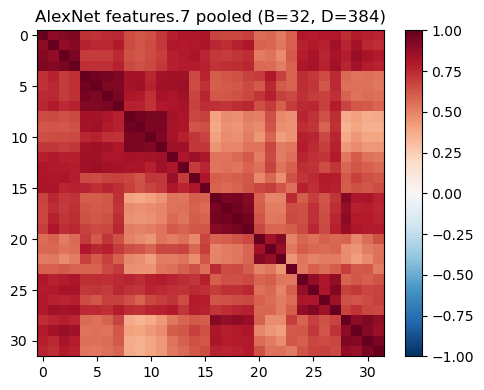

In [72]:
# correlation matrix for a chosen layer

layer_to_plot = "features.7"  # last conv ReLU
reps = pooled[layer_to_plot]   # (B, C)

C = np.corrcoef(reps)

plt.figure(figsize=(5,4))
plt.imshow(C, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
plt.title(f"AlexNet {layer_to_plot} pooled (B={reps.shape[0]}, D={reps.shape[1]})")
plt.colorbar()
plt.tight_layout()
plt.show()


/tmp/ipykernel_2857240/3906910981.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


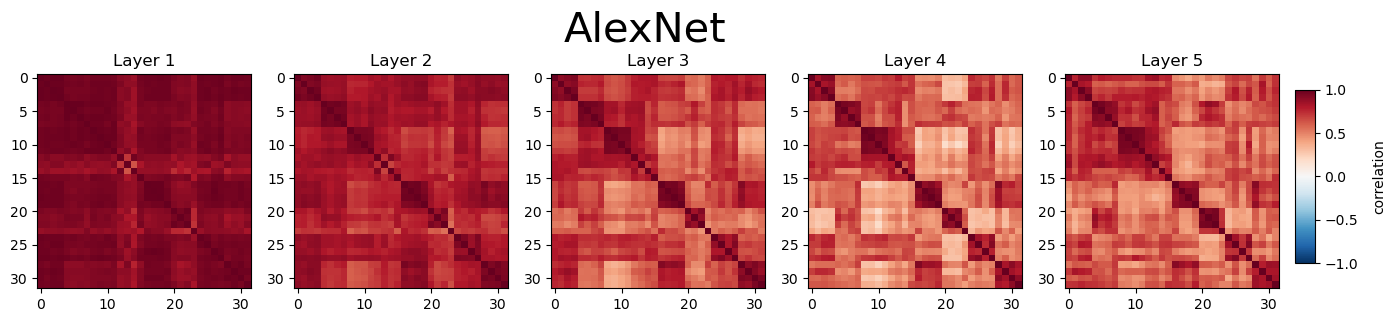

In [73]:
# visualize the rcm for different layers
layers = list(pooled.keys())
nlayers = len(layers)
fig, axes = plt.subplots(1, nlayers, figsize=(2*nlayers+3, 3))
axes = axes.ravel()
for li in range(nlayers):
    reps = pooled[layers[li]]
    C = np.corrcoef(reps)
    img = axes[li].imshow(C, cmap='RdBu_r', vmin=-1, vmax=1)
    axes[li].set_title(f"Layer {li+1}")
plt.suptitle("AlexNet", fontsize=30)
# add a colorbar outside the last plot, but keep the last image the same size as others
# add code

# get position of last axis

pos = axes[-1].get_position()
cax = fig.add_axes([pos.x1 + 0.1, pos.y0-0.07, 0.015, pos.height])

cbar = fig.colorbar(img, cax=cax)
cbar.set_label('correlation', rotation=90, labelpad=10)
plt.tight_layout()
# save the figure
plt.savefig("../figures/alexnet_corr_matrix.png", dpi=300, bbox_inches='tight')

plt.show()